In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================================
# 1. 数据加载
# =============================================================================

# 从本地读取贷款预测数据集（注意：路径需根据实际存放位置进行调整）
df = pd.read_csv(r'D:\Loan_Default_Prediction\data\Training Data.csv')
print("=" * 60)


In [3]:
# =============================================================================
# 2. 数据概览（初步探索）
# =============================================================================
print("1. 数据概览")
print("=" * 60)

# 输出数据集维度，了解样本量和特征数量
print(f"数据规模：{df.shape[0]}行 ✖ {df.shape[1]}列")

# describe()：输出数值型特征的描述性统计，包括均值、标准差、分位数等
# 可用于快速判断数据的中心趋势与离散程度
print(f"数据统计：{df.describe()}")

# info()：输出各列的非空值数量与数据类型，用于识别缺失值与类型异常
print(f"数据预览：{df.info()}")

# 业务说明：数据集中部分字段以"月"为单位存储，分析时需注意单位换算
print("=" * 60)
print("字段单位说明")
print("=" * 60)
print("""
Age                 → 年 (21-79岁)
Experience          → 月 (建议除以12转换为年)
CURRENT_JOB_YRS     → 月 (建议除以12转换为年)
CURRENT_HOUSE_YRS   → 月 (建议除以12转换为年)
Income              → 万美元
Risk_Flag           → 0=安全, 1=风险
""")

1. 数据概览
数据规模：252000行 ✖ 13列
数据统计：                  Id        Income            Age     Experience  \
count  252000.000000  2.520000e+05  252000.000000  252000.000000   
mean   126000.500000  4.997117e+06      49.954071      10.084437   
std     72746.278255  2.878311e+06      17.063855       6.002590   
min         1.000000  1.031000e+04      21.000000       0.000000   
25%     63000.750000  2.503015e+06      35.000000       5.000000   
50%    126000.500000  5.000694e+06      50.000000      10.000000   
75%    189000.250000  7.477502e+06      65.000000      15.000000   
max    252000.000000  9.999938e+06      79.000000      20.000000   

       CURRENT_JOB_YRS  CURRENT_HOUSE_YRS      Risk_Flag  
count    252000.000000      252000.000000  252000.000000  
mean          6.333877          11.997794       0.123000  
std           3.647053           1.399037       0.328438  
min           0.000000          10.000000       0.000000  
25%           3.000000          11.000000       0.000000  
5


2. 数据清洗
✅ 没有缺失值！
重复行数：0

异常值检测（使用 IQR）：
----------------------------------------
Income: 0个异常值
Age: 0个异常值
Experience: 0个异常值
CURRENT_JOB_YRS: 0个异常值
CURRENT_HOUSE_YRS: 0个异常值

分类列取值：
Married/Single: ['single', 'married']
House_Ownership: ['rented', 'norent_noown', 'owned']
Car_Ownership: ['no', 'yes']


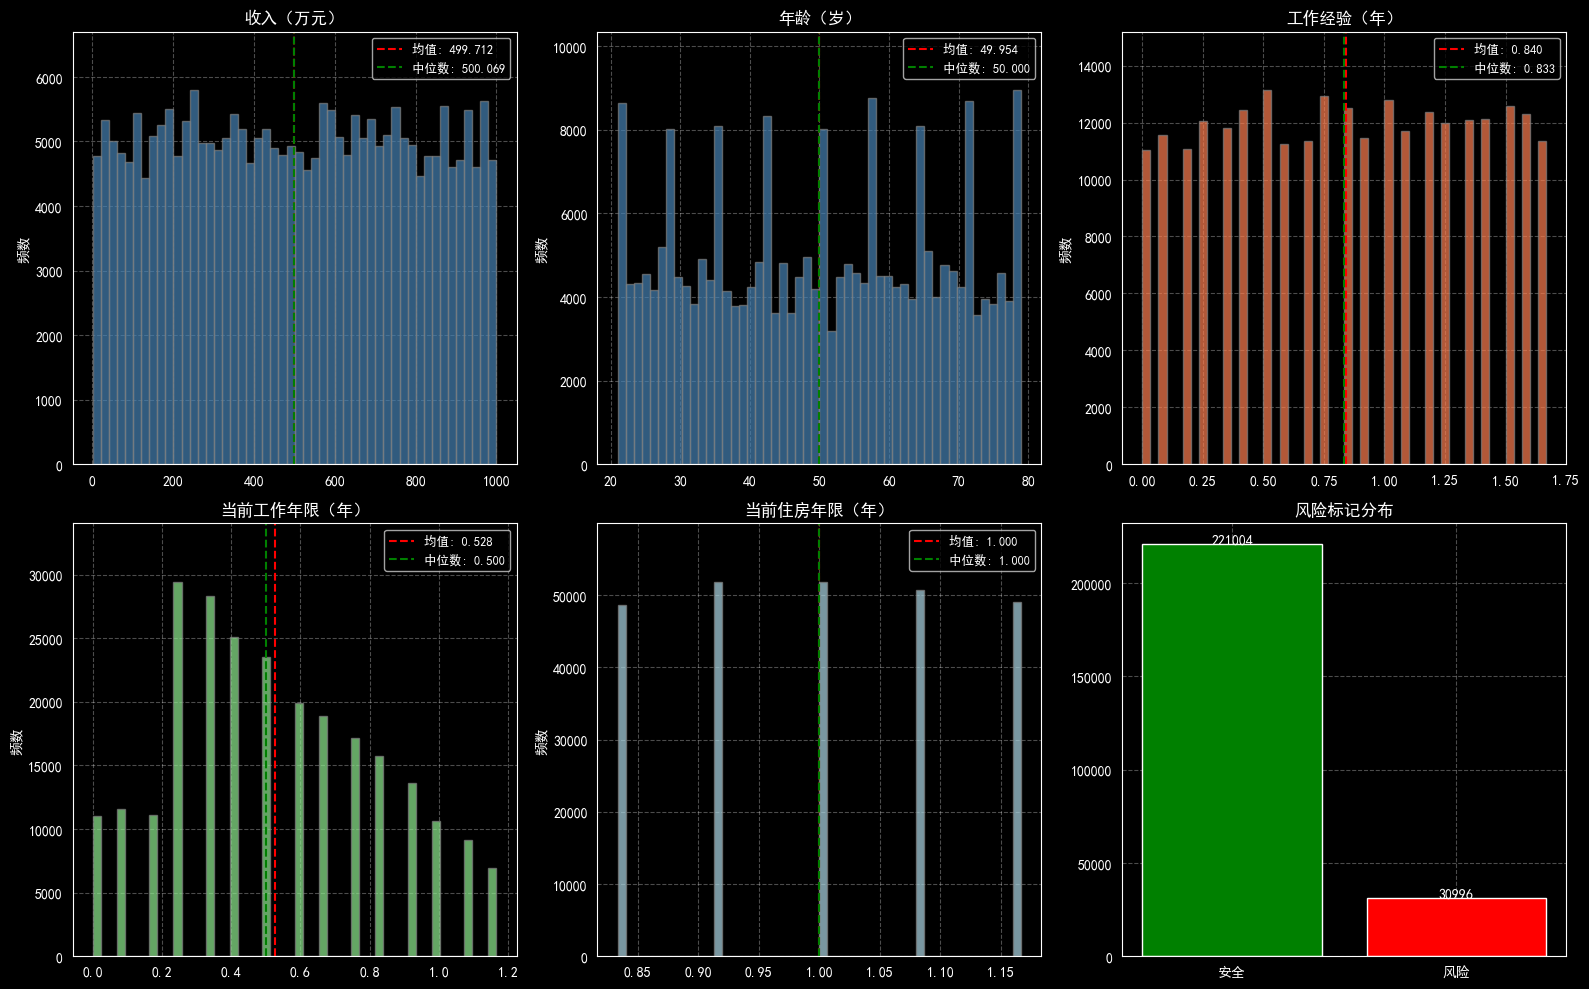

In [4]:
# =============================================================================
# 3. 数据清洗
# =============================================================================
print("\n" + "=" * 60)
print("2. 数据清洗")
print("=" * 60)

# --------------------------------------------------------------------------
# 3.1 缺失值检测
# --------------------------------------------------------------------------
# 检查各列是否存在空值，若存在需根据业务逻辑决定填充或删除策略
missing = df.isnull().sum()
if missing.sum() > 0:
    print("缺失值统计：")
    print(missing[missing > 0])
else:
    print("✅ 没有缺失值！")

# --------------------------------------------------------------------------
# 3.2 重复值检测
# --------------------------------------------------------------------------
# 检查是否存在完全重复的记录，重复样本可能引入数据偏差
duplicates = df.duplicated().sum()
print(f"重复行数：{duplicates}")

# --------------------------------------------------------------------------
# 3.3 异常值检测（基于 IQR 方法）
# --------------------------------------------------------------------------
# 使用四分位距法（IQR）识别异常值：超出 [Q1 - 1.5*IQR, Q3 + 1.5*IQR] 区间
# 的样本点视为异常值，需结合业务判断是否剔除或修正
print("\n异常值检测（使用 IQR）：")
print("-" * 40)
for col in ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlies = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outlies)}个异常值")

# --------------------------------------------------------------------------
# 3.4 分类变量取值检查
# --------------------------------------------------------------------------
# 查看分类变量的所有取值，确认数据规范性与是否存在异常类别
print("\n分类列取值：")
for col in ['Married/Single', 'House_Ownership', 'Car_Ownership']:
    print(f"{col}: {df[col].unique().tolist()}")

# =============================================================================
# 4. 单变量分析（数值型特征）
# =============================================================================

# 设置 Matplotlib 中文字体，解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建数据副本，进行单位转换（月 → 年，收入 → 万元），便于统一分析
df_plot = df.copy()
df_plot['Income'] = df_plot['Income'] / 10000          # 收入单位：万美元 → 万元
for col in ['Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']:
    df_plot[col] = df_plot[col] / 12                    # 月 → 年

# 构建 2×3 的子图布局，分别绘制各数值特征的分布直方图
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# 配置待绘制的数值特征列表
num_cols = ['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']
titles = ['收入（万元）', '年龄（岁）', '工作经验（年）', '当前工作年限（年）', '当前住房年限（年）']
colors = ['steelblue', 'steelblue', 'coral', 'lightgreen', 'lightblue']

for i, col in enumerate(num_cols):
    data = df_plot[col]

    # 绘制直方图，bins=50 以精细呈现数据分布形态
    axes[i].hist(data, bins=50, color=colors[i], edgecolor='gray', alpha=0.7)

    # 标注均值与中位数：若两者偏差较大，提示数据存在偏态分布
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'均值: {data.mean():.3f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', label=f'中位数: {data.median():.3f}')
    axes[i].set_title(titles[i])

    # 图例统一置于右上角，避免遮挡数据主体
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].set_ylabel('频数')

    # 添加淡色网格线，提升数值读取的便捷性
    axes[i].grid(linestyle='--', alpha=0.3)
    axes[i].set_axisbelow(True)

    # 动态调整 Y 轴上限，为图例预留视觉空间
    y_min, y_max = axes[i].get_ylim()
    axes[i].set_ylim(y_min, y_max * 1.10)

# 第 6 个子图：风险标记分布（目标变量）
counts = df['Risk_Flag'].value_counts()
axes[5].bar(['安全', '风险'], counts.values, color=['green', 'red'])
axes[5].set_title('风险标记分布')
for j, v in enumerate(counts.values):
    axes[5].text(j, v + 500, str(v), ha='center')
axes[5].grid(linestyle='--', alpha=0.3)
axes[5].set_axisbelow(True)

# 自动调整子图间距，防止标签重叠
plt.tight_layout()
plt.savefig('单变量分析图.png', dpi=300)   # 高分辨率导出，适用于报告展示
plt.show()



4. 单变量分析 - 分类型


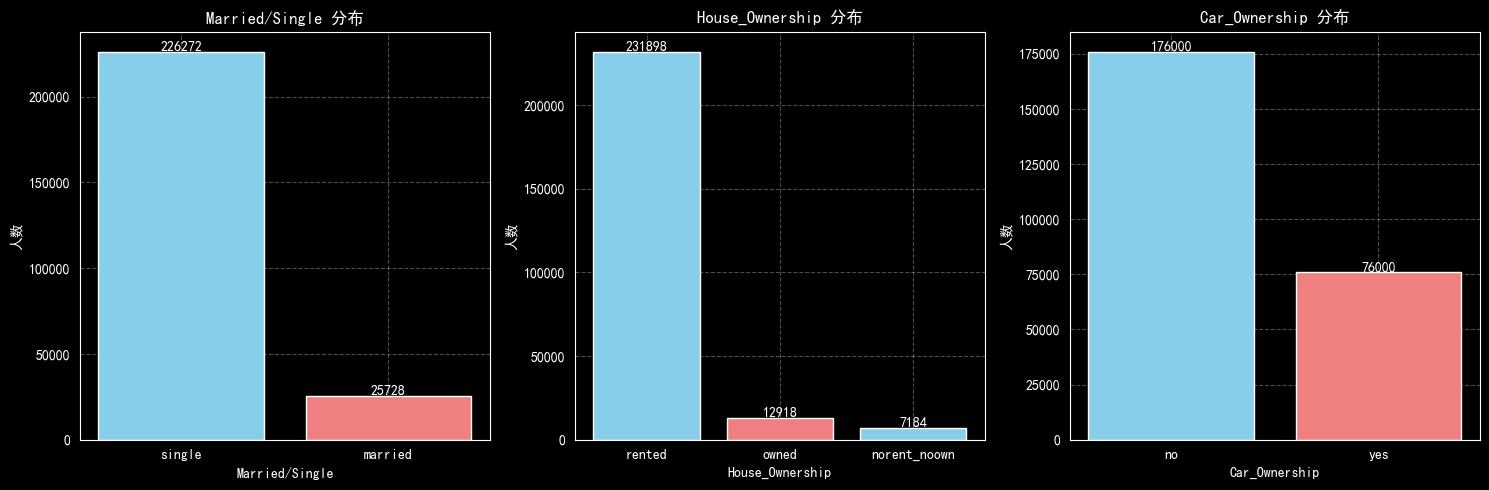


5. 相关性分析
相关性矩阵：
                     Income       Age  Experience  CURRENT_JOB_YRS  \
Income             1.000000 -0.000652    0.006422         0.007045   
Age               -0.000652  1.000000   -0.001118         0.002154   
Experience         0.006422 -0.001118    1.000000         0.646098   
CURRENT_JOB_YRS    0.007045  0.002154    0.646098         1.000000   
CURRENT_HOUSE_YRS -0.002397 -0.020134    0.019309         0.005372   
Risk_Flag         -0.003091 -0.021809   -0.034523        -0.016942   

                   CURRENT_HOUSE_YRS  Risk_Flag  
Income                     -0.002397  -0.003091  
Age                        -0.020134  -0.021809  
Experience                  0.019309  -0.034523  
CURRENT_JOB_YRS             0.005372  -0.016942  
CURRENT_HOUSE_YRS           1.000000  -0.004375  
Risk_Flag                  -0.004375   1.000000  


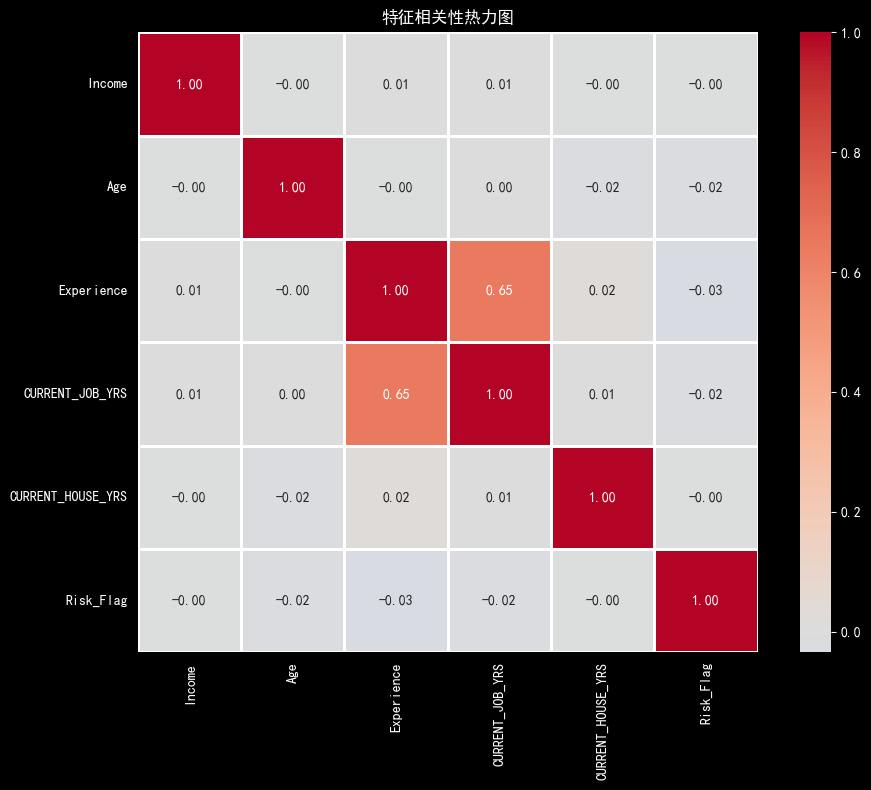


6. 目标变量分析 (Risk_Flag)
高风险比例：12.30%
低风险人数：221004
高风险人数：30996


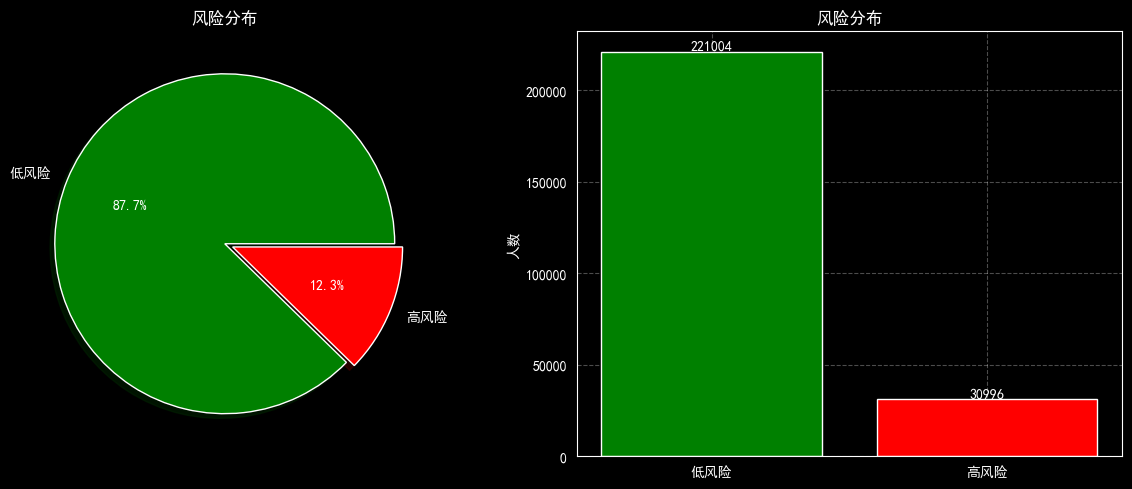


7. 特征与风险的关系
婚姻状况与风险：
Married/Single
married    0.102456
single     0.125336
Name: Risk_Flag, dtype: float64

住房情况与风险：
House_Ownership
norent_noown    0.099527
owned           0.089797
rented          0.125577
Name: Risk_Flag, dtype: float64

车辆拥有与风险：
Car_Ownership
no     0.128188
yes    0.110987
Name: Risk_Flag, dtype: float64


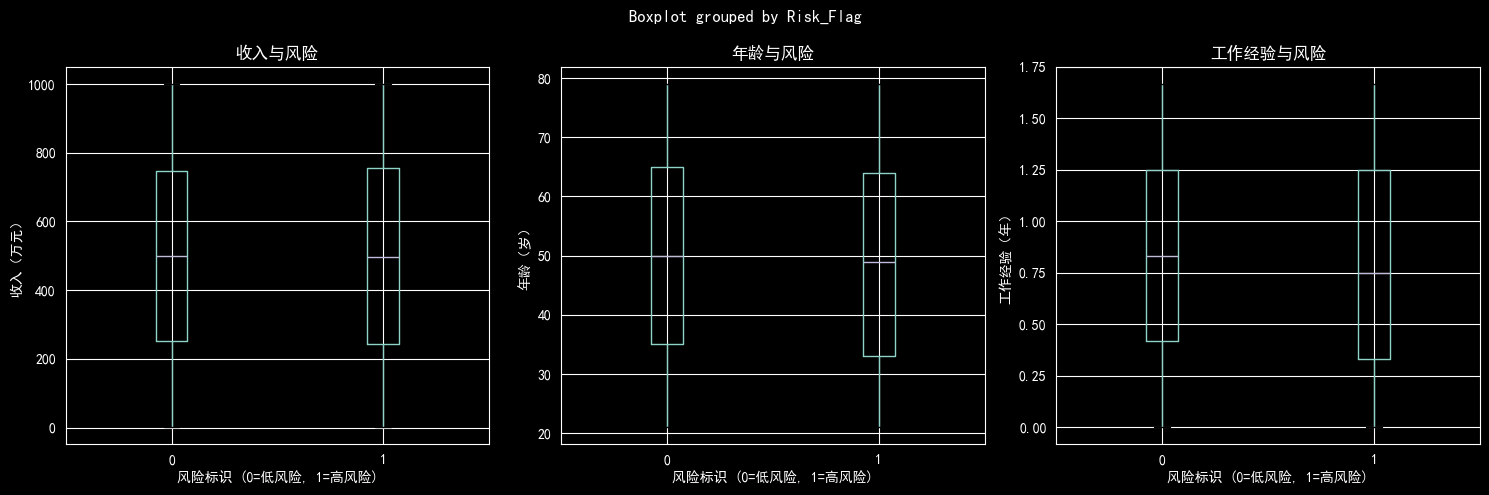


8. 统计检验 - 分类变量与风险的关系
Married/Single：
  卡方统计量：111.8920
  p值：0.000000
  是否显著：✅ 显著

House_Ownership：
  卡方统计量：182.9892
  p值：0.000000
  是否显著：✅ 显著

Car_Ownership：
  卡方统计量：145.4237
  p值：0.000000
  是否显著：✅ 显著


9. 分析总结
📊 数据特征：
  - 总样本量：252000 条
  - 特征数：13 列
  - 高风险比例：12.30%

🔍 关键发现：
  - 平均收入：499.71 万元
  - 平均年龄：50.0 岁
  - 平均工作经验：0.8 年

📈 风险相关因素：
  - 单身人群风险率更高
  - 租房人群风险率更高
  - 无车人群风险率更高

💡 后续建模建议：
  1. 采用 Logistic Regression、Random Forest 等算法构建违约预测模型
  2. 对类别特征进行 One-Hot 编码或目标编码处理
  3. 针对样本不平衡问题，可引入 SMOTE 过采样或欠采样策略
  4. 基于特征重要性分析进行特征筛选，优化模型泛化能力


In [5]:
# =============================================================================
# 5. 单变量分析（分类型特征）
# =============================================================================
print("\n" + "=" * 60)
print("4. 单变量分析 - 分类型")
print("=" * 60)

# 绘制分类变量的柱状图，展示各类别样本量分布
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cat_cols = ['Married/Single', 'House_Ownership', 'Car_Ownership']

for i, col in enumerate(cat_cols):
    value_counts = df[col].value_counts()
    axes[i].bar(value_counts.index, value_counts.values, color=['skyblue', 'lightcoral'])
    axes[i].set_title(f'{col} 分布')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('人数')
    axes[i].grid(linestyle='--', alpha=0.3)
    axes[i].set_axisbelow(True)

    # 在柱顶添加数值标签，提升信息传达效率
    for j, v in enumerate(value_counts.values):
        axes[i].text(j, v + 500, str(v), ha='center')

plt.tight_layout()
plt.savefig('分类列分布图.png', dpi=300)
plt.show()

# =============================================================================
# 6. 多变量分析：相关性矩阵与热力图
# =============================================================================
print("\n" + "=" * 60)
print("5. 相关性分析")
print("=" * 60)

# 计算数值特征之间的皮尔逊相关系数，识别特征间的线性依赖关系
corr = df_plot[['Income', 'Age', 'Experience', 'CURRENT_JOB_YRS',
                'CURRENT_HOUSE_YRS', 'Risk_Flag']].corr()
print("相关性矩阵：")
print(corr)

# 绘制热力图，以颜色深浅直观表示相关系数的大小与方向
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.savefig('相关性热力图.png', dpi=300)
plt.show()

# =============================================================================
# 7. 目标变量分析（Risk_Flag）
# =============================================================================
print("\n" + "=" * 60)
print("6. 目标变量分析 (Risk_Flag)")
print("=" * 60)

# 计算高风险样本占比，评估数据集平衡性
risk_rate = df['Risk_Flag'].mean()
print(f"高风险比例：{risk_rate:.2%}")
print(f"低风险人数：{len(df[df['Risk_Flag'] == 0])}")
print(f"高风险人数：{len(df[df['Risk_Flag'] == 1])}")

# 饼图 + 柱状图组合展示风险分布，兼顾直观性与精确性
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['低风险', '高风险']
sizes = [len(df[df['Risk_Flag'] == 0]), len(df[df['Risk_Flag'] == 1])]
colors_pie = ['green', 'red']

# 饼图：突出显示高风险占比
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors_pie,
            explode=(0, 0.05), shadow=True)
axes[0].set_title('风险分布')

# 柱状图：精确展示各分类的绝对数量
axes[1].bar(labels, sizes, color=colors_pie)
axes[1].set_ylabel('人数')
axes[1].set_title('风险分布')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 1000, str(v), ha='center')
    axes[i].grid(linestyle='--', alpha=0.3)
    axes[i].set_axisbelow(True)

plt.tight_layout()
plt.savefig('风险分布图.png', dpi=300)
plt.show()

# =============================================================================
# 8. 特征与风险关系分析（分组统计 + 箱线图）
# =============================================================================
print("\n" + "=" * 60)
print("7. 特征与风险的关系")
print("=" * 60)

# 按分类变量分组，计算各组风险率，识别高风险人群画像
married_risk = df.groupby('Married/Single')['Risk_Flag'].mean()
print("婚姻状况与风险：")
print(married_risk)

house_risk = df.groupby('House_Ownership')['Risk_Flag'].mean()
print("\n住房情况与风险：")
print(house_risk)

car_risk = df.groupby('Car_Ownership')['Risk_Flag'].mean()
print("\n车辆拥有与风险：")
print(car_risk)

# 箱线图：对比高风险/低风险人群在连续特征上的分布差异
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_plot.boxplot(column='Income', by='Risk_Flag', ax=axes[0])
axes[0].set_title('收入与风险')
axes[0].set_xlabel('风险标识 (0=低风险, 1=高风险)')
axes[0].set_ylabel('收入（万元）')

df_plot.boxplot(column='Age', by='Risk_Flag', ax=axes[1])
axes[1].set_title('年龄与风险')
axes[1].set_xlabel('风险标识 (0=低风险, 1=高风险)')
axes[1].set_ylabel('年龄（岁）')

df_plot.boxplot(column='Experience', by='Risk_Flag', ax=axes[2])
axes[2].set_title('工作经验与风险')
axes[2].set_xlabel('风险标识 (0=低风险, 1=高风险)')
axes[2].set_ylabel('工作经验（年）')

plt.tight_layout()
plt.savefig('特征与风险关系图.png', dpi=300)
plt.show()

# =============================================================================
# 9. 统计检验：卡方检验（分类变量与风险的关系）
# =============================================================================
from scipy.stats import chi2_contingency

print("\n" + "=" * 60)
print("8. 统计检验 - 分类变量与风险的关系")
print("=" * 60)

# 卡方独立性检验：判断分类变量与 Risk_Flag 之间是否存在统计学上的显著关联
# H0（原假设）：两变量相互独立；H1：两变量存在关联
# 若 p < 0.05，则拒绝 H0，认为该特征与风险显著相关
def chi2_test(df, col, target='Risk_Flag'):
    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    return chi2, p, dof

for col in ['Married/Single', 'House_Ownership', 'Car_Ownership']:
    chi2, p, dof = chi2_test(df, col)
    print(f"{col}：")
    print(f"  卡方统计量：{chi2:.4f}")
    print(f"  p值：{p:.6f}")
    print(f"  是否显著：{'✅ 显著' if p < 0.05 else '❌ 不显著'}")
    print()

# =============================================================================
# 10. 分析结论与业务洞察
# =============================================================================
print("\n" + "=" * 60)
print("9. 分析总结")
print("=" * 60)

print("📊 数据特征：")
print(f"  - 总样本量：{len(df)} 条")
print(f"  - 特征数：{len(df.columns)} 列")
print(f"  - 高风险比例：{risk_rate:.2%}")

print("\n🔍 关键发现：")
print(f"  - 平均收入：{df_plot['Income'].mean():.2f} 万元")
print(f"  - 平均年龄：{df_plot['Age'].mean():.1f} 岁")
print(f"  - 平均工作经验：{df_plot['Experience'].mean():.1f} 年")

print("\n📈 风险相关因素：")
if married_risk['single'] > married_risk['married']:
    print("  - 单身人群风险率更高")
else:
    print("  - 已婚人群风险率更高")

if house_risk['rented'] > house_risk['owned']:
    print("  - 租房人群风险率更高")
else:
    print("  - 自有住房人群风险率更高")

if car_risk['no'] > car_risk['yes']:
    print("  - 无车人群风险率更高")
else:
    print("  - 有车人群风险率更高")

print("\n💡 后续建模建议：")
print("  1. 采用 Logistic Regression、Random Forest 等算法构建违约预测模型")
print("  2. 对类别特征进行 One-Hot 编码或目标编码处理")
print("  3. 针对样本不平衡问题，可引入 SMOTE 过采样或欠采样策略")
print("  4. 基于特征重要性分析进行特征筛选，优化模型泛化能力")